# Identificabilidad de la partición y estructura de continuo

**Sección 4.4.7.3 de la tesis** — análisis de estabilidad que complementa el bootstrap re-clustering
(notebook `04_clusterizacion_tematica.ipynb`, Sección 8) para responder una pregunta más profunda:
¿está la partición en k=7 *identificada de forma única* por los datos?

Se reproducen los tres diagnósticos reportados en la tesis, todos sobre el mismo pipeline
TF-IDF → LSA (r=176) → K-means:

1. **Estabilidad multi-semilla**: ARI por pares entre 25 particiones con distintas semillas.
2. **Tabla 4.4 con barras de error**: media ± DE de Silhouette, Calinski-Harabasz y Davies-Bouldin
   sobre 25 semillas, para k = 3…15.
3. **Clustering de consenso** (Monti et al., 2003): PAC (Şenbabaoğlu et al., 2014) y matriz de
   co-asociación (Figura 4.28a).

> **Hallazgo**: las tres vías convergen en el mismo diagnóstico — el corpus **no** se organiza en
> clusters discretos, sino en un gran núcleo metodológico que se comporta como un continuo semántico
> más unas pocas especializaciones periféricas nítidas.


## 0. Configuración y pipeline (TF-IDF → LSA r=176)

In [1]:

import json, re, unicodedata
from pathlib import Path
from itertools import combinations
import collections

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score, adjusted_rand_score)
from dateutil import parser as dtparser
import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
try:
    stopwords.words("english")
except LookupError:
    nltk.download("stopwords")

np.seterr(all="ignore")
RANDOM_STATE = 42
DATA_JSON = Path("../data/reorganized_data_c_CLEAN_NORMALIZADO.json")
FIGS = Path("../results/figures"); FIGS.mkdir(parents=True, exist_ok=True)
TABLES = Path("../results/tables"); TABLES.mkdir(parents=True, exist_ok=True)

with open(DATA_JSON, "r", encoding="utf-8") as f:
    records = json.load(f)

def strip_accents(s):
    return "".join(c for c in unicodedata.normalize("NFKD", s) if not unicodedata.combining(c))
def tok(t):
    return re.findall(r"[A-Za-zÀ-ÖØ-öø-ÿ]+", t)
en = set(stopwords.words("english")); es = set(stopwords.words("spanish"))
stop = {w.lower() for w in (en | es | {strip_accents(w) for w in en|es} |
        {"et","al","via","doi","preprint","article","study","journal","revista","volume","issue","http","https"})}
names = set()
for r in records:
    for a in r.get("Autores") or []:
        if isinstance(a, dict):
            for k in ("nombre","universidad"):
                if a.get(k): names.add(a[k])
excl = {strip_accents(x).lower() for t_ in names for x in tok(str(t_)) if len(strip_accents(x))>=2}
stem = SnowballStemmer("english")
def prep(t):
    return " ".join(stem.stem(x) for x in tok(strip_accents(str(t).lower())) if len(x)>=2 and x not in stop and x not in excl)

docs = [" ".join([r.get("Articulo","") or "", r.get("abstract","") or "",
        (", ".join(map(str, r.get("keywords"))) if isinstance(r.get("keywords"), list) else (r.get("keywords") or ""))])
        for r in records]
texts = [prep(d) for d in docs]

X = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_df=0.95).fit_transform(texts)
Z = TruncatedSVD(n_components=min(200, X.shape[0]-1), random_state=RANDOM_STATE).fit_transform(X)
N = Z.shape[0]
print(f"TF-IDF {X.shape} -> LSA {Z.shape}")


TF-IDF (177, 1247) -> LSA (177, 176)


## 1. Estabilidad multi-semilla (k=7)

Se ejecuta K-means (k=7, n_init=50) con 25 semillas distintas y se compara la concordancia entre
todas las particiones. Si el paisaje de optimización fuese estructurado, las 25 soluciones
coincidirían (ARI≈1). Si es plano, discreparán pese a inercias casi idénticas.


In [2]:

SEEDS = list(range(25))
labs = [KMeans(n_clusters=7, random_state=s, n_init=50, max_iter=1000).fit_predict(Z) for s in SEEDS]
inert = [KMeans(n_clusters=7, random_state=s, n_init=50, max_iter=1000).fit(Z).inertia_ for s in SEEDS]
aris = np.array([adjusted_rand_score(labs[i], labs[j]) for i, j in combinations(range(25), 2)])
inert = np.array(inert)
print(f"ARI por pares: media={aris.mean():.3f}  DE={aris.std():.3f}  min={aris.min():.3f}  max={aris.max():.3f}")
print(f"Inercia: media={inert.mean():.3f}  CV={inert.std()/inert.mean()*100:.2f}%")
print(f"Particiones distintas: {len({tuple(l) for l in map(tuple, labs)})} de 25")


ARI por pares: media=0.369  DE=0.066  min=0.213  max=0.585
Inercia: media=148.022  CV=0.25%
Particiones distintas: 25 de 25


## 2. Tabla 4.4 con barras de error (media ± DE, 25 semillas)

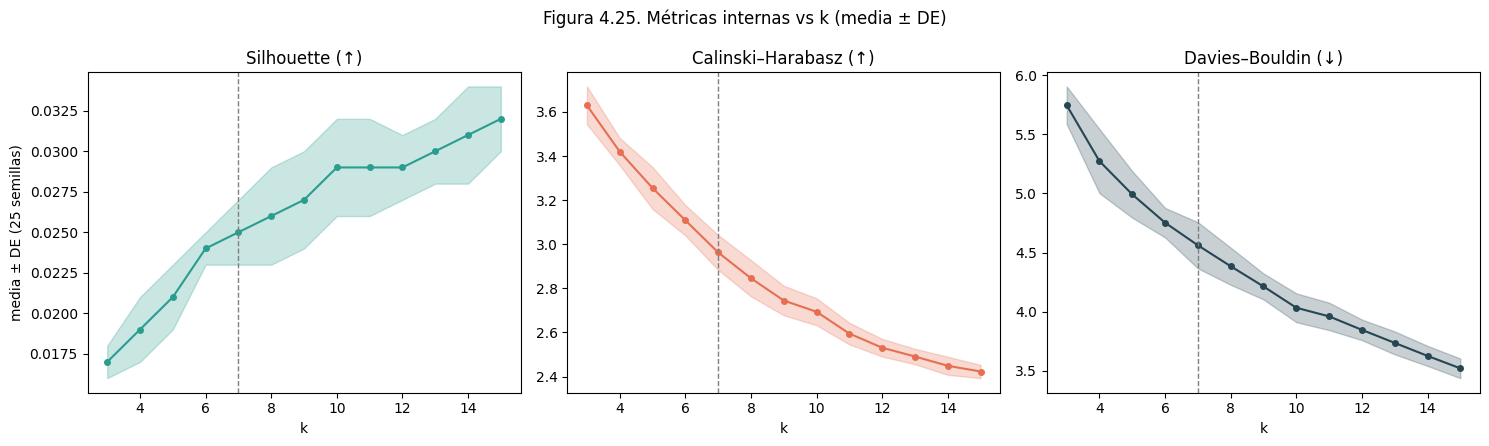

Las tres métricas son monótonas en k; ningún óptimo local en k=7.


In [3]:

rows = []
for k in range(3, 16):
    S=[];C=[];D=[]
    for s in SEEDS:
        l = KMeans(n_clusters=k, random_state=s, n_init=50, max_iter=1000).fit_predict(Z)
        S.append(silhouette_score(Z,l)); C.append(calinski_harabasz_score(Z,l)); D.append(davies_bouldin_score(Z,l))
    rows.append({"k":k, "sil_mean":np.mean(S),"sil_sd":np.std(S),
                 "ch_mean":np.mean(C),"ch_sd":np.std(C),"db_mean":np.mean(D),"db_sd":np.std(D)})
df44 = pd.DataFrame(rows).round(3)
df44.to_csv(TABLES/"tabla_4_4_errorbars.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(1,3, figsize=(15,4.5))
for a,(mc,sc,name,col) in zip(ax,[("sil_mean","sil_sd","Silhouette (↑)","#2a9d8f"),
        ("ch_mean","ch_sd","Calinski–Harabasz (↑)","#e76f51"),("db_mean","db_sd","Davies–Bouldin (↓)","#264653")]):
    m=df44[mc].values; s=df44[sc].values
    a.plot(df44.k, m, "-o", color=col, lw=1.5, ms=4); a.fill_between(df44.k, m-s, m+s, color=col, alpha=0.25)
    a.axvline(7, color="gray", ls="--", lw=1); a.set_xlabel("k"); a.set_title(name)
ax[0].set_ylabel("media ± DE (25 semillas)")
fig.suptitle("Figura 4.25. Métricas internas vs k (media ± DE)"); fig.tight_layout()
fig.savefig(FIGS/"fig_4_25_kselection_errorbars.png", dpi=160, bbox_inches="tight"); plt.show()
print("Las tres métricas son monótonas en k; ningún óptimo local en k=7.")


## 3. Clustering de consenso: PAC y matriz de co-asociación

Sobre 500 remuestreos (80 % del corpus), se construye la matriz de consenso para cada k. El **PAC**
(proporción de pares con co-asociación en (0.1, 0.9)) mide la ambigüedad: menor = clusters más
nítidos. La **matriz de co-asociación** para k=7 se ordena por su partición de consenso.


In [4]:

B, prop = 500, 0.8
m = int(prop*N)

def consensus_M(k, seed0):
    co = np.zeros((N,N)); cnt = np.zeros((N,N)); rng = np.random.default_rng(seed0)
    for _ in range(B):
        idx = rng.choice(N, size=m, replace=False)
        lab = KMeans(n_clusters=k, n_init=1, init="random", max_iter=300,
                     random_state=int(rng.integers(0,1e9))).fit_predict(Z[idx])
        for c in np.unique(lab):
            mem = idx[lab==c]; co[np.ix_(mem,mem)] += 1
        cnt[np.ix_(idx,idx)] += 1
    return np.where(cnt>0, co/cnt, 0.0)

def pac(M, u1=0.1, u2=0.9):
    v = M[np.triu_indices(N,1)]; return float(np.mean((v>u1)&(v<u2)))

pac_rows = [{"k":k, "PAC":round(pac(consensus_M(k, 3000+k)),3)} for k in range(3,16)]
df_pac = pd.DataFrame(pac_rows)
df_pac.to_csv(TABLES/"pac_por_k.csv", index=False, encoding="utf-8-sig")
print(df_pac.to_string(index=False))
print(f"\nPAC en k=7 = {df_pac.loc[df_pac.k==7,'PAC'].iloc[0]:.3f} (alto); PAC monótono -> sin número natural de clusters")


 k   PAC
 3 0.996
 4 0.990
 5 0.942
 6 0.820
 7 0.683
 8 0.581
 9 0.494
10 0.422
11 0.362
12 0.325
13 0.288
14 0.261
15 0.232

PAC en k=7 = 0.683 (alto); PAC monótono -> sin número natural de clusters


Consenso k=7 tamaños: {np.int64(0): 60, np.int64(1): 22, np.int64(2): 23, np.int64(3): 47, np.int64(4): 8, np.int64(5): 6, np.int64(6): 11}
Co-asociación media dentro=0.327  entre=0.139  separación=0.188


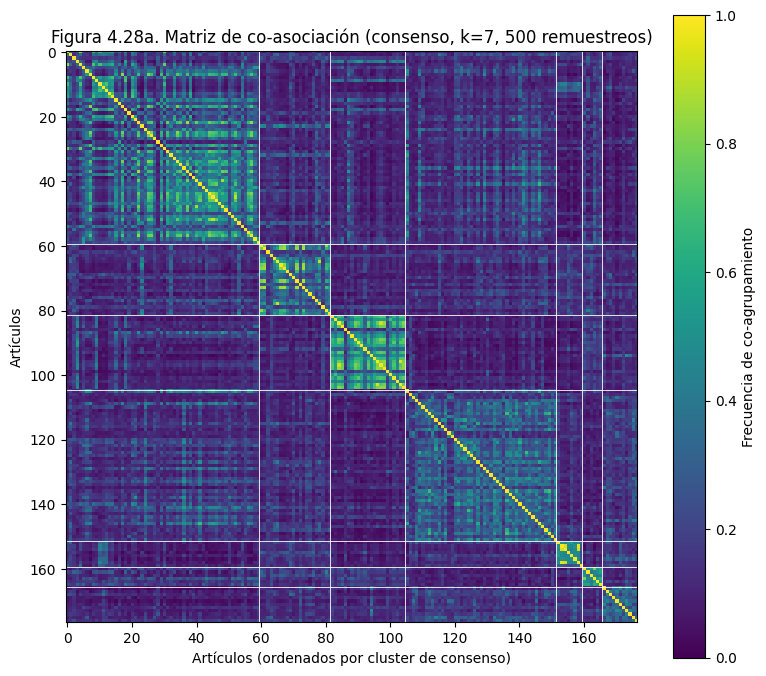

In [5]:

# Matriz de co-asociación k=7 + partición de consenso
M = consensus_M(7, 7176)
Dd = 1.0 - M; np.fill_diagonal(Dd, 0.0)
cons = AgglomerativeClustering(n_clusters=7, metric="precomputed", linkage="average").fit_predict(Dd)
within = np.mean([M[i,j] for i in range(N) for j in range(i+1,N) if cons[i]==cons[j]])
between = np.mean([M[i,j] for i in range(N) for j in range(i+1,N) if cons[i]!=cons[j]])
print(f"Consenso k=7 tamaños: {dict(sorted(collections.Counter(cons).items()))}")
print(f"Co-asociación media dentro={within:.3f}  entre={between:.3f}  separación={within-between:.3f}")

order = np.argsort(cons); Mord = M[np.ix_(order,order)]
fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(Mord, cmap="viridis", vmin=0, vmax=1, aspect="equal")
b = 0
for c in sorted(set(cons)):
    b += list(cons[order]).count(c); ax.axhline(b-0.5, color="white", lw=0.6); ax.axvline(b-0.5, color="white", lw=0.6)
ax.set_title("Figura 4.28a. Matriz de co-asociación (consenso, k=7, 500 remuestreos)")
ax.set_xlabel("Artículos (ordenados por cluster de consenso)"); ax.set_ylabel("Artículos")
fig.colorbar(im, label="Frecuencia de co-agrupamiento"); fig.tight_layout()
fig.savefig(FIGS/"fig_4_28a_coasociacion_k7.png", dpi=160); plt.show()


## 4. Síntesis

Los tres diagnósticos coinciden:

- **Multi-semilla**: ARI≈0.37 entre soluciones, inercia CV≈0.25 % → la partición no está identificada
  de forma única; fijar la semilla da replicabilidad, no estabilidad.
- **Métricas monótonas**: ninguna presenta óptimo en k=7 → no hay un número natural de clusters.
- **PAC alto (≈0.68 en k=7) + co-asociación difusa en el núcleo**: el corpus es un **continuo
  semántico** con un gran bloque metodológico difuso (distribuciones/inferencia/bayesiano/bondad de
  ajuste) y unas pocas especializaciones periféricas nítidas (control de procesos, muestreo, espacial).

Esto reafirma la solución k=7 en su estatus correcto: una **lente interpretativa parsimoniosa** de la
composición temática gruesa, no una afirmación de siete clusters latentes discretos.
